<a href="https://colab.research.google.com/github/dhimas-ra/football-project/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


matches = pd.read_csv("/content/drive/MyDrive/Predicting Match Win Probability Using Last 3 Matches Statistics/matches.csv", sep= ";")
h2h = pd.read_csv("/content/drive/MyDrive/Predicting Match Win Probability Using Last 3 Matches Statistics/h2h.csv", sep= ";")
players = pd.read_csv("/content/drive/MyDrive/Predicting Match Win Probability Using Last 3 Matches Statistics/players.csv", sep= ";")
players

,team,player,goals,assists,avg_rating
0,Man City,Matheus Nunes,0,1,7.3
1,Man City,Khusanov,0,0,7.7
2,Man City,Rodri,0,0,7.8
3,Liverpool,Szobozlai,2,0,8.3
4,Liverpool,Van Dijk,0,0,7.1
5,Liverpool,Gravenberch,1,0,7.5


In [112]:
city = matches[matches['team'] == 'Man City']
liverpool = matches[matches['team'] == 'Liverpool']

# LAST 3 MATCHES STATS
city_avg_goal = city['goal_scored'].mean()
city_concede = city['goal_concended'].mean()
city_avg_possesion = city['possesion'].mean()
city_avg_shots = city['shots'].mean()
city_avg_xg = city['xg'].mean()

liverpool_avg_goal = liverpool['goal_scored'].mean()
liverpool_concede = liverpool['goal_concended'].mean()
liverpool_avg_possesion = liverpool['possesion'].mean()
liverpool_avg_shots = liverpool['shots'].mean()
liverpool_avg_xg = liverpool['xg'].mean()

# 3 LAST H2H
city_liv_h2h = h2h[
    ((h2h['home'] == 'Liverpool') & (h2h['away'] == 'Man City')) |
    ((h2h['home'] == 'Man City') & (h2h['away'] == 'Liverpool')) |
    ((h2h['home'] == 'Man City') & (h2h['away'] == 'Liverpool'))
]

city_wins = (city_liv_h2h['winner'] == 'Man City').sum()
total_matches = len(city_liv_h2h)
h2h_city_winrate = city_wins / total_matches

liverpool_wins = (city_liv_h2h['winner'] == 'Liverpool').sum()
h2h_liverpool_winrate = liverpool_wins / total_matches

draws = (city_liv_h2h['winner'] == 'Draw').sum()

city_pos_score = city_avg_possesion / 100
liverpool_pos_score = liverpool_avg_possesion / 100

# PLAYERS H2H LAST 3 MATCHES
city_players = players[players['team'] == 'Man City'].copy()
liverpool_players = players[players['team'] == 'Liverpool'].copy()

city_players['impact'] = (
    city_players['goals'] * 0.3 +
    city_players['assists'] * 0.3 +
    city_players['avg_rating'] * 0.5
)

liverpool_players['impact'] = (
    liverpool_players['goals'] * 0.3 +
    liverpool_players['assists'] * 0.3 +
    liverpool_players['avg_rating'] * 0.5
)

city_player_score = city_players['impact'].mean()
liverpool_player_score = liverpool_players['impact'].mean()

# TEAM STRENGTH

city_strength = (
    city_avg_goal * 0.4 +
    city_avg_xg * 0.3 +
    city_avg_shots * 0.2 +
    city_pos_score * 0.1 +
    h2h_city_winrate * 0.3 +
    city_player_score * 0.2 -
    city_concede * 0.3
)

liverpool_strength = (
    liverpool_avg_goal * 0.4 +
    liverpool_avg_xg * 0.3 +
    liverpool_avg_shots * 0.2 +
    liverpool_pos_score * 0.1 +
    h2h_liverpool_winrate * 0.3 +
    liverpool_player_score * 0.2 -
    liverpool_concede * 0.3
)

# Draw Probabilty

city_strength = 5.55
liverpool_strength = 6.39

diff = abs(city_strength - liverpool_strength)

base_draw = 0.30
adjusment = 0.15

draw_prob = base_draw + (diff * adjusment)
draw_prob = max(0.10, draw_prob)

remaining_prob = 1 - draw_prob

city_strength = city_strength * remaining_prob
liverpool_strength = liverpool_strength * remaining_prob


total = city_strength + liverpool_strength
city_prob = (city_strength / total) * remaining_prob
liverpool_prob = remaining_prob - city_prob

summary = pd.DataFrame({
    "Team": ["Manchester City", "Liverpool"],
    "Strength": [city_strength, liverpool_strength],
    "Win Probability": [city_prob, liverpool_prob],
})
summary["Win Probability (%)"] = (
   summary["Win Probability"] * 100
).round(1).astype(str) + "%"

summary = summary.drop(columns=["Win Probability"])

print(summary)

print("Draw Probability:", round(draw_prob*100,1), "%")

#print(f"Man City win probability: {city_prob:.2%}")
#print(f"Liverpool win probability: {liverpool_prob:.2%}")

              Team  Strength Win Probability (%)
0  Manchester City   3.18570               26.7%
1        Liverpool   3.66786               30.7%
Draw Probability: 42.6 %


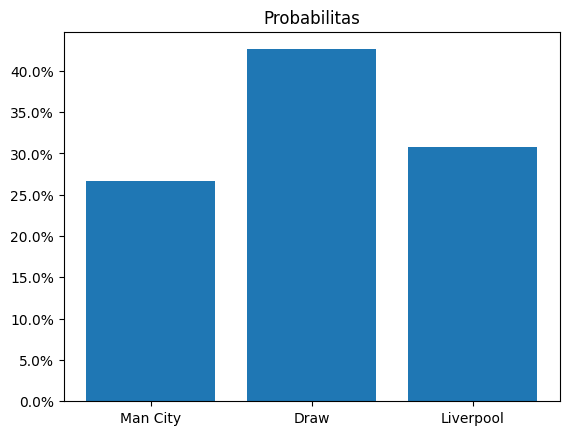

In [113]:
teams = ['Man City', 'Draw', 'Liverpool']
probs = [city_prob,draw_prob, liverpool_prob]

plt.bar(teams, probs)
plt.title("Probabilitas")

# Format y-axis as percentages
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.show()